# Descripción del Conjunto de Datos
El dataset contiene información sobre los clientes de un banco y sus transacciones financieras durante un período de 12 meses. Incluye datos sobre facturación, transacciones, actividad con tarjetas de crédito/débito y características demográficas de los clientes.

## Resumen de los Atributos
- Datos Demográficos: Edad, renta, región de residencia, antigüedad en el banco.
- Uso de Productos Bancarios: Número de cuentas, tarjetas de crédito (TC), tarjetas de débito (TD), créditos hipotecarios.
- Transacciones y Facturación: Monto facturado (Fac_T01 - Fac_T12), número de transacciones (Txs_T01 - Txs_T12), uso de líneas de crédito (UsoL1_T12, UsoL2_T12).
- Actividad Mensual: Indicadores de uso activo de la tarjeta (FlgAct_T01 - FlgAct_T12).
Objetivo del Análisis

El propósito de este análisis es predecir el churn (deserción) de clientes bancarios. Para ello, se estudian patrones de gasto, transacciones y actividad con el fin de identificar señales tempranas de abandono. Esta información permitirá al banco diseñar estrategias de retención y fidelización de clientes.

In [252]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedShuffleSplit

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Leemos los datos
data = pd.read_csv(r'data/Monopoly.csv', sep=',', skiprows=1)

# copia de los datos para mantener una version sin cambios
df = data.copy()

# revisar los datos, primeras 5 filas
df.head()

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target,Unnamed: 574
0,1,160,M,13.0,43,NaN,130,1,1,0,...,33000,0.0,1099866.0,0.0,1099866.0,15080,0.0,R,0,NaN
1,2,160,H,13.0,46,143640.0,69,1,0,0,...,300000,0.0,214592.0,0.0,214592.0,83596,0.0,R,0,NaN
2,3,170,H,13.0,45,929106.0,24,1,1,0,...,216676,0.0,0.0,0.0,7400.0,0,0.0,T,0,NaN
3,4,151,H,13.0,46,172447.0,134,0,1,0,...,60000,0.0,272762.0,0.0,272762.0,10591,0.0,R,0,NaN
4,5,170,H,13.0,46,805250.0,116,0,1,1,...,272925,0.0,249562.0,0.0,75339.0,377782,0.0,R,0,NaN


In [9]:
# variables categoricas a eliminar IndRev12-01
deleted = df.select_dtypes(include='object').iloc[:, 1:]
df = df.drop(deleted, axis=1)
# Borramos ID y Unnamed
df = df.drop(['Id', 'Unnamed: 574'], axis=1)

In [11]:
# Revisar datos duplicados
df.index.is_unique

True

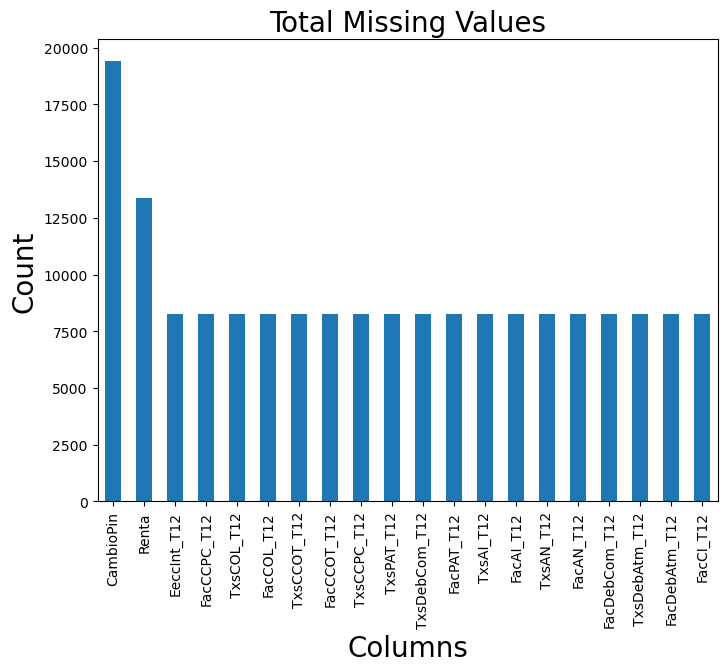

In [13]:
# Verificar los primeros 20 columnas con nan
total_nan = df.isnull().sum().sort_values(ascending = False)
total_select = total_nan.head(20)
total_select.plot(kind='bar', figsize=(8,6), fontsize=10)

plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)
plt.show()

In [15]:
# verificar todos los nans
cols_nan = [[col, df[col].isna().sum()] for col in df.columns if df[col].isna().sum() > 0]
pd.DataFrame(cols_nan)

,0,1
0,Sexo,1
1,Region,53
2,Renta,13365
3,CambioPin,19388
4,FlgAct_T12,8251
...,...,...
494,EeccNac_T02,12
495,EeccInt_T02,12
496,UsoL1_T02,12
497,UsoL2_T02,12


# Exploración, Limpieza de datos y Feature Engineering

Recopilamos los datos correspondientes al primer trimestre del año. Estas columnas contienen información detallada sobre los promedios de facturación, la actividad comercial y el promedio de transacciones realizadas por los clientes durante los meses de enero, febrero y marzo. Este análisis nos permitirá obtener una visión completa del rendimiento de nuestras operaciones en este periodo específico del año, facilitando la toma de decisiones informadas y estratégicas.

In [18]:
# separacion de las columnnas importantes de facturaciones en una division trimestral desde enero a marzo

tri_01 = df[[
    'Fac_T01', 'Fac_T02', 'Fac_T03',          # Promedios de facturacion mensual de los clientes desde el mes 1 al 3
    'FlgAct_T01', 'FlgAct_T02', 'FlgAct_T03', # Actividad de los clientes desde el mes 1 al 3 
    'Txs_T01', 'Txs_T02', 'Txs_T03',          # Promedio de transacciones realizadas por los clientes desde el mes 1 al 3 
]]

Además, hemos incluido las siguientes columnas, las cuales considero esenciales para comprender a nuestros clientes y su comportamiento. Estas columnas son: sexo, edad, renta, región, antigüedad, internauta, CUPO_L1, cuenta corriente (Ctacte), débito, monoproducto y tarjeta de crédito (TC). Esta información nos permitirá realizar un análisis profundo y detallado de las características demográficas y financieras de nuestros clientes, lo cual es fundamental para desarrollar estrategias efectivas de marketing y mejorar la satisfacción del cliente.

In [20]:
# observaremos las siguientes dimensiones del data original
df_clas = (df[['Sexo', 'Edad', 'Renta', 'Region', 'Antiguedad', 'Internauta', 'CUPO_L1', 'Ctacte', 'Debito', 'Monoproducto', 'TC']])
df_clas.head()

,Sexo,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC
0,M,43,NaN,13.0,130,1,798000,1,1,0,3
1,H,46,143640.0,13.0,69,1,750000,1,0,0,1
2,H,45,929106.0,13.0,24,1,1350000,1,1,0,2
3,H,46,172447.0,13.0,134,0,1570800,0,0,1,2
4,H,46,805250.0,13.0,116,0,2762000,1,0,0,3


Para completar nuestro dataframe para nuestro objetivo de la clasificacion de churn y para mejorar la capacidad predictiva del modelo, se generaron nuevas variables basadas en patrones de uso y cambios en comportamiento.

### ✅ Facturación y Consumo

Suma_Facturacion y Promedio_Facturacion → Capturan el volumen total y promedio mensual de gasto.
Tasa_Cambio_Fact → Mide la variación en el consumo mes a mes.

### ✅ Frecuencia de Uso

Suma_Transacciones y Promedio_Transacciones → Número total y promedio de transacciones mensuales.
Tasa_Cambio_Txs → Identifica reducción en la cantidad de transacciones.

### ✅ Actividad del Cliente

Meses_Activo → Cuenta cuántos meses el cliente ha usado activamente su tarjeta.
Tasa_Cambio_Actividad → Detecta clientes que han dejado de usar productos recientemente.

In [30]:
# Facturación:
df_clas['Suma_Facturacion'] = tri_01[['Fac_T01', 'Fac_T02', 'Fac_T03']].sum(axis=1)
df_clas['Promedio_Facturacion'] = tri_01[['Fac_T01', 'Fac_T02', 'Fac_T03']].mean(axis=1)
df_clas['Tasa_Cambio_Fact'] = np.where(tri_01['Fac_T01'] != 0, 
                                       tri_01['Fac_T03'] / tri_01['Fac_T01'], 
                                       np.nan) -1 

# Transacciones:
df_clas['Suma_Transacciones'] = tri_01[['Txs_T01', 'Txs_T02', 'Txs_T03']].sum(axis=1)
df_clas['Promedio_Transacciones'] = tri_01[['Txs_T01', 'Txs_T02', 'Txs_T03']].mean(axis=1)
df_clas['Tasa_Cambio_Txs'] = np.where(tri_01['Txs_T01'] != 0, 
                                       tri_01['Txs_T03'] / tri_01['Txs_T01'], 
                                       np.nan) -1 

# Actividad:
df_clas['Meses_Activo'] = tri_01[['FlgAct_T01', 'FlgAct_T02', 'FlgAct_T03']].sum(axis=1)
df_clas['Tasa_Cambio_Actividad'] = np.where(tri_01['FlgAct_T01'] != 0, 
                                       tri_01['FlgAct_T03'] / tri_01['FlgAct_T01'], 
                                       np.nan) -1 

Definimos a los clientes "churn" como aquellos clientes que no han mostrado ninguna actividad durante los últimos dos meses consecutivos. Este criterio nos permite identificar a los clientes que, por diversas razones, han dejado de interactuar con nuestros productos o servicios. Al detectar a tiempo estos patrones de inactividad, podemos implementar estrategias de retención adecuadas para recuperar y reenganchar a estos clientes, asegurando así una mayor fidelización y satisfacción a largo plazo.

In [38]:
df_clas['Churn'] = ((tri_01['FlgAct_T03'] == 0) & (tri_01['FlgAct_T02'] == 0)).astype(int)

In [40]:
df_clas

,Sexo,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,Suma_Facturacion,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn
0,M,43,NaN,13.0,130,1,798000,1,1,0,3,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,1
1,H,46,143640.0,13.0,69,1,750000,1,0,0,1,138218.0,46072.666667,-0.951982,3.0,1.000000,0.000000,3.0,0.0,0
2,H,45,929106.0,13.0,24,1,1350000,1,1,0,2,255915.0,85305.000000,-0.965244,10.0,3.333333,-0.333333,3.0,0.0,0
3,H,46,172447.0,13.0,134,0,1570800,0,0,1,2,46880.0,15626.666667,1.270816,3.0,1.000000,0.000000,3.0,0.0,0
4,H,46,805250.0,13.0,116,0,2762000,1,0,0,3,746406.0,248802.000000,0.370731,27.0,9.000000,-0.200000,3.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,H,51,364978.0,13.0,57,1,999000,1,1,0,3,146936.0,48978.666667,-0.361865,15.0,5.000000,0.000000,3.0,0.0,0
51120,H,51,625376.0,13.0,39,1,1744200,1,1,0,1,399672.0,133224.000000,7.391049,5.0,1.666667,2.000000,3.0,0.0,0
51121,H,47,806220.0,13.0,153,1,1061000,1,1,0,2,24259.0,8086.333333,NaN,1.0,0.333333,NaN,1.0,NaN,0
51122,M,47,NaN,13.0,11,1,1612000,1,0,0,1,159982.0,53327.333333,-0.770604,4.0,1.333333,-0.500000,3.0,0.0,0


In [42]:
df_clas['Churn'].value_counts()

Churn
0    42279
1     8845
Name: count, dtype: int64

Observamos que nuestra variable objetivo "Churn" está desbalanceada, ya que tenemos 42,279 clientes clasificados como 0 y 8,845 clientes clasificados como 1. Esta desproporción indica un desbalance significativo en nuestro conjunto de datos, lo cual podría afectar negativamente el rendimiento y la precisión de nuestros modelos predictivos. Es crucial abordar este desequilibrio para mejorar la calidad de nuestras predicciones y asegurarnos de que nuestros análisis reflejen con precisión el comportamiento real de nuestros clientes. Podemos considerar la aplicación de técnicas de balanceo de datos.

In [45]:
correlation = df_clas.corr(numeric_only= True)
churn_corr = correlation['Churn'].sort_values(ascending=False)
top_corr = churn_corr[abs(churn_corr) > 0.5]
top_corr

Churn                    1.000000
Tasa_Cambio_Actividad   -0.590244
Meses_Activo            -0.763730
Name: Churn, dtype: float64

Hemos identificado que las variables con mayor correlación con el "churn" son la tasa de cambio de actividad y los meses activos. Este hallazgo es significativo, ya que nos permite enfocar nuestros esfuerzos de análisis y estrategia en estas dos variables clave. La tasa de cambio de actividad refleja cómo varía la frecuencia de las interacciones de un cliente con nuestros productos o servicios, mientras que los meses activos indican el tiempo total que un cliente ha estado comprometido con nuestra marca. Al analizar y monitorear estas variables, podemos obtener información valiosa sobre los patrones de comportamiento de nuestros clientes

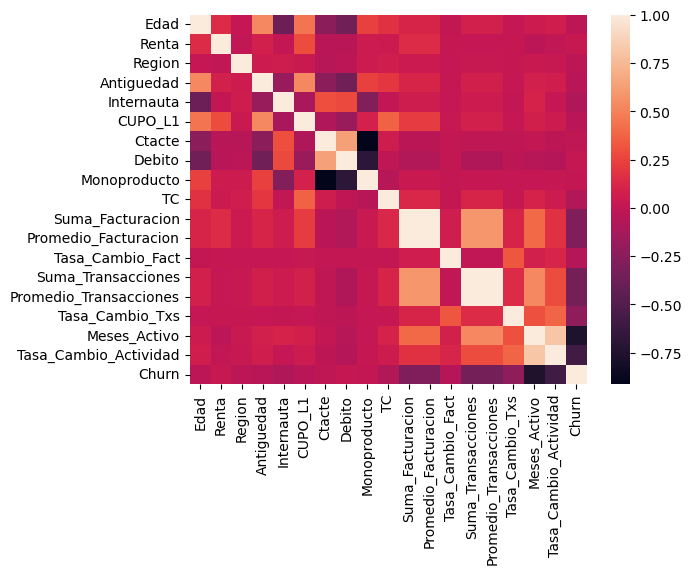

In [48]:
sns.heatmap(correlation)
plt.show()

#### Transformación e imputacion de nans

In [50]:
# transformamos nuestro variable categorica sexo con get_dummies
df_clas = pd.get_dummies(df_clas, columns=['Sexo'], dtype=int)

In [52]:
nans = [x for x in df_clas.columns if df_clas[x].isna().sum() > 0]
nans

['Renta',
 'Region',
 'Tasa_Cambio_Fact',
 'Tasa_Cambio_Txs',
 'Tasa_Cambio_Actividad']

In [56]:
# imputamos los nans de la lista que obtuvimos
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='distance', metric='nan_euclidean')

for column in nans:
    df_clas[[column]] = imputer.fit_transform(df_clas[[column]])

print(df_clas.isna().sum())

Edad                      0
Renta                     0
Region                    0
Antiguedad                0
Internauta                0
CUPO_L1                   0
Ctacte                    0
Debito                    0
Monoproducto              0
TC                        0
Suma_Facturacion          0
Promedio_Facturacion      0
Tasa_Cambio_Fact          0
Suma_Transacciones        0
Promedio_Transacciones    0
Tasa_Cambio_Txs           0
Meses_Activo              0
Tasa_Cambio_Actividad     0
Churn                     0
Sexo_H                    0
Sexo_M                    0
dtype: int64


In [58]:
df_clas.head()

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,...,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn,Sexo_H,Sexo_M
0,43,663077.078726,13.0,130,1,798000,1,1,0,3,...,0.000000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0,1
1,46,143640.000000,13.0,69,1,750000,1,0,0,1,...,46072.666667,-0.951982,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
2,45,929106.000000,13.0,24,1,1350000,1,1,0,2,...,85305.000000,-0.965244,10.0,3.333333,-0.333333,3.0,0.000000,0,1,0
3,46,172447.000000,13.0,134,0,1570800,0,0,1,2,...,15626.666667,1.270816,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
4,46,805250.000000,13.0,116,0,2762000,1,0,0,3,...,248802.000000,0.370731,27.0,9.000000,-0.200000,3.0,0.000000,0,1,0


In [64]:
for col in df_clas.columns:
    if df_clas[col].dtype == 'float64':
        df_clas[col] = df_clas[col].astype('float32')
    if df_clas[col].dtype == 'int64':
        df_clas[col] = df_clas[col].astype('int32')

df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51124 entries, 0 to 51123
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Edad                    51124 non-null  int32  
 1   Renta                   51124 non-null  float32
 2   Region                  51124 non-null  float32
 3   Antiguedad              51124 non-null  int32  
 4   Internauta              51124 non-null  int32  
 5   CUPO_L1                 51124 non-null  int32  
 6   Ctacte                  51124 non-null  int32  
 7   Debito                  51124 non-null  int32  
 8   Monoproducto            51124 non-null  int32  
 9   TC                      51124 non-null  int32  
 10  Suma_Facturacion        51124 non-null  float32
 11  Promedio_Facturacion    51124 non-null  float32
 12  Tasa_Cambio_Fact        51124 non-null  float32
 13  Suma_Transacciones      51124 non-null  float32
 14  Promedio_Transacciones  51124 non-null

In [66]:
df_clas.to_csv('DataFrame_for_classification.csv', index=False)

## Balance de nuestra variable objetivo Churn

Procederemos a balancear nuestra variable "churn", ya que actualmente contamos con 42,279 registros clasificados como "no-churn" y 8,845 registros clasificados como "churn". Esta desproporción puede influir negativamente en la precisión y el rendimiento de nuestros modelos predictivos, al sesgar los resultados hacia la clase mayoritaria

In [68]:
ds = pd.read_csv('DataFrame_for_classification.csv')

In [70]:
ds

,Edad,Renta,Region,Antiguedad,Internauta,CUPO_L1,Ctacte,Debito,Monoproducto,TC,...,Promedio_Facturacion,Tasa_Cambio_Fact,Suma_Transacciones,Promedio_Transacciones,Tasa_Cambio_Txs,Meses_Activo,Tasa_Cambio_Actividad,Churn,Sexo_H,Sexo_M
0,43,663077.06,13.0,130,1,798000,1,1,0,3,...,0.0000,1.539435,0.0,0.000000,0.236879,0.0,-0.182342,1,0,1
1,46,143640.00,13.0,69,1,750000,1,0,0,1,...,46072.6680,-0.951982,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
2,45,929106.00,13.0,24,1,1350000,1,1,0,2,...,85305.0000,-0.965244,10.0,3.333333,-0.333333,3.0,0.000000,0,1,0
3,46,172447.00,13.0,134,0,1570800,0,0,1,2,...,15626.6670,1.270816,3.0,1.000000,0.000000,3.0,0.000000,0,1,0
4,46,805250.00,13.0,116,0,2762000,1,0,0,3,...,248802.0000,0.370731,27.0,9.000000,-0.200000,3.0,0.000000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,51,364978.00,13.0,57,1,999000,1,1,0,3,...,48978.6680,-0.361865,15.0,5.000000,0.000000,3.0,0.000000,0,1,0
51120,51,625376.00,13.0,39,1,1744200,1,1,0,1,...,133224.0000,7.391049,5.0,1.666667,2.000000,3.0,0.000000,0,1,0
51121,47,806220.00,13.0,153,1,1061000,1,1,0,2,...,8086.3335,1.539435,1.0,0.333333,0.236879,1.0,-0.182342,0,1,0
51122,47,663077.06,13.0,11,1,1612000,1,0,0,1,...,53327.3320,-0.770604,4.0,1.333333,-0.500000,3.0,0.000000,0,0,1


<Axes: xlabel='Churn'>

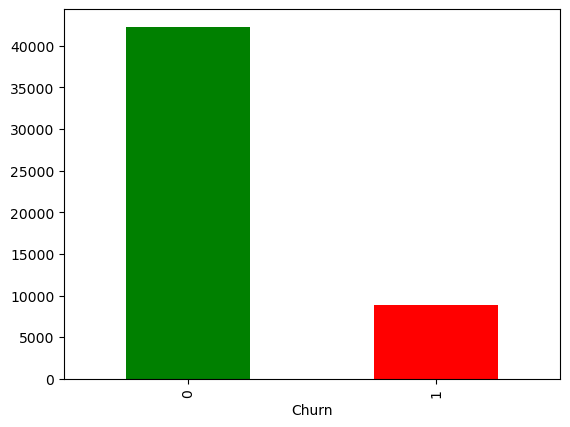

In [72]:
ds['Churn'].value_counts().plot.bar(color=['green', 'red'])

# Regresión logística con variable churn no balanceada y balanceada

In [74]:
def split_data(df):
    X = df.loc[ : , df.columns != 'Churn']
    y = df['Churn'].astype('int')
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state = 42)

In [76]:
X_train, X_test, y_train, y_test = split_data(ds)

In [78]:
model = LogisticRegression(random_state=42, 
                              max_iter = 1000)

# Train the model
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [80]:
accuracy_score(y_test, preds)

0.9772127139364303

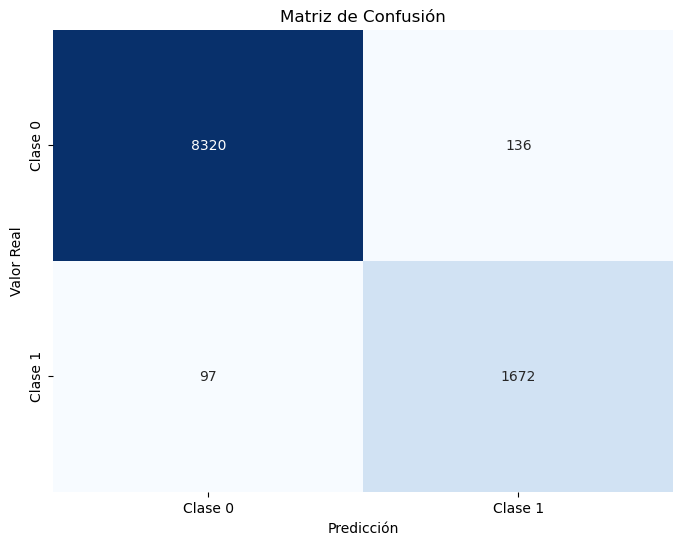

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      8456
           1       0.92      0.95      0.93      1769

    accuracy                           0.98     10225
   macro avg       0.96      0.96      0.96     10225
weighted avg       0.98      0.98      0.98     10225

-------------------------------------------------
curva de roc y area bajo la curva


0.9645417531940018

In [82]:
# matriz de confusion
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# reporte
print(classification_report(y_test, preds))
print("-------------------------------------------------")

# curva de roc y area bajo la curva
print("curva de roc y area bajo la curva")
roc_auc_score(y_test, preds)

In [84]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Create a SMOTE sampler
smote_sampler = SMOTE(random_state = 42)

In [86]:
# Resample training data using SMOTE
X_smo, y_smo = smote_sampler.fit_resample(X_train, y_train)

<Axes: xlabel='Churn'>

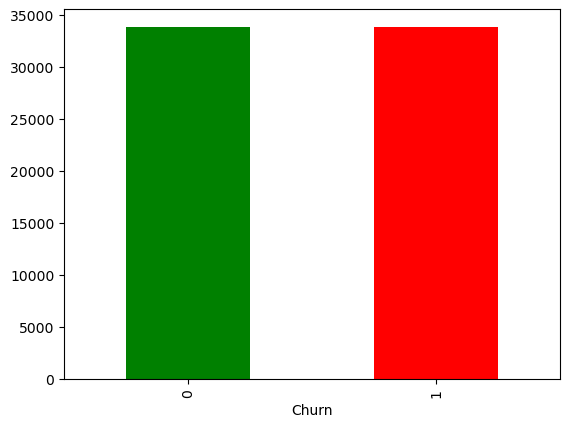

In [88]:
# Visualize classes
y_smo.value_counts().plot.bar(color=['green', 'red'])

In [90]:
# Re-train the model with resampled data
model.fit(X_smo, y_smo)
preds = model.predict(X_test)

In [92]:
accuracy_score(y_test, preds)

0.9540342298288509

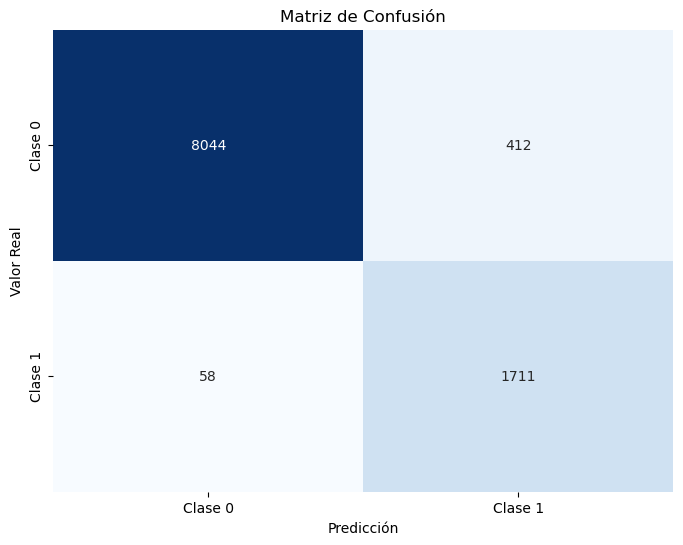

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      8456
           1       0.81      0.97      0.88      1769

    accuracy                           0.95     10225
   macro avg       0.90      0.96      0.93     10225
weighted avg       0.96      0.95      0.96     10225

-------------------------------------------------
curva de roc y area bajo la curva


0.9592451571878344

In [94]:
# matriz de confusion
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# reporte
print(classification_report(y_test, preds))
print("-------------------------------------------------")

# curva de roc y area bajo la curva
print("curva de roc y area bajo la curva")
roc_auc_score(y_test, preds)

balancear la variable "churn" mejora la capacidad del modelo para detectar casos de churn, aunque puede afectar levemente la precisión general.

# Algorítmo de árbol de decisión

In [183]:
dt_model = DecisionTreeClassifier(random_state=42)

In [185]:
dt_model.fit(X_smo, y_smo.values.ravel())

DecisionTreeClassifier(random_state=42)

In [187]:
y_pred = dt_model.predict(X_test)

In [189]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [191]:
evaluate_metrics(y_test, y_pred)

{'accuracy': 0.9998044009779951,
 'recall': 1.0,
 'precision': 0.9988706945228685,
 'f1score': 0.9994350282485875}

In [132]:
def plot_decision_tree(model, feature_names):
    plt.subplots(figsize=(25, 20)) 
    tree.plot_tree(model, 
                       feature_names=feature_names,  
                       filled=True)
    plt.show()

In [142]:
feature_names = ds.loc[ : , ds.columns != 'Churn']

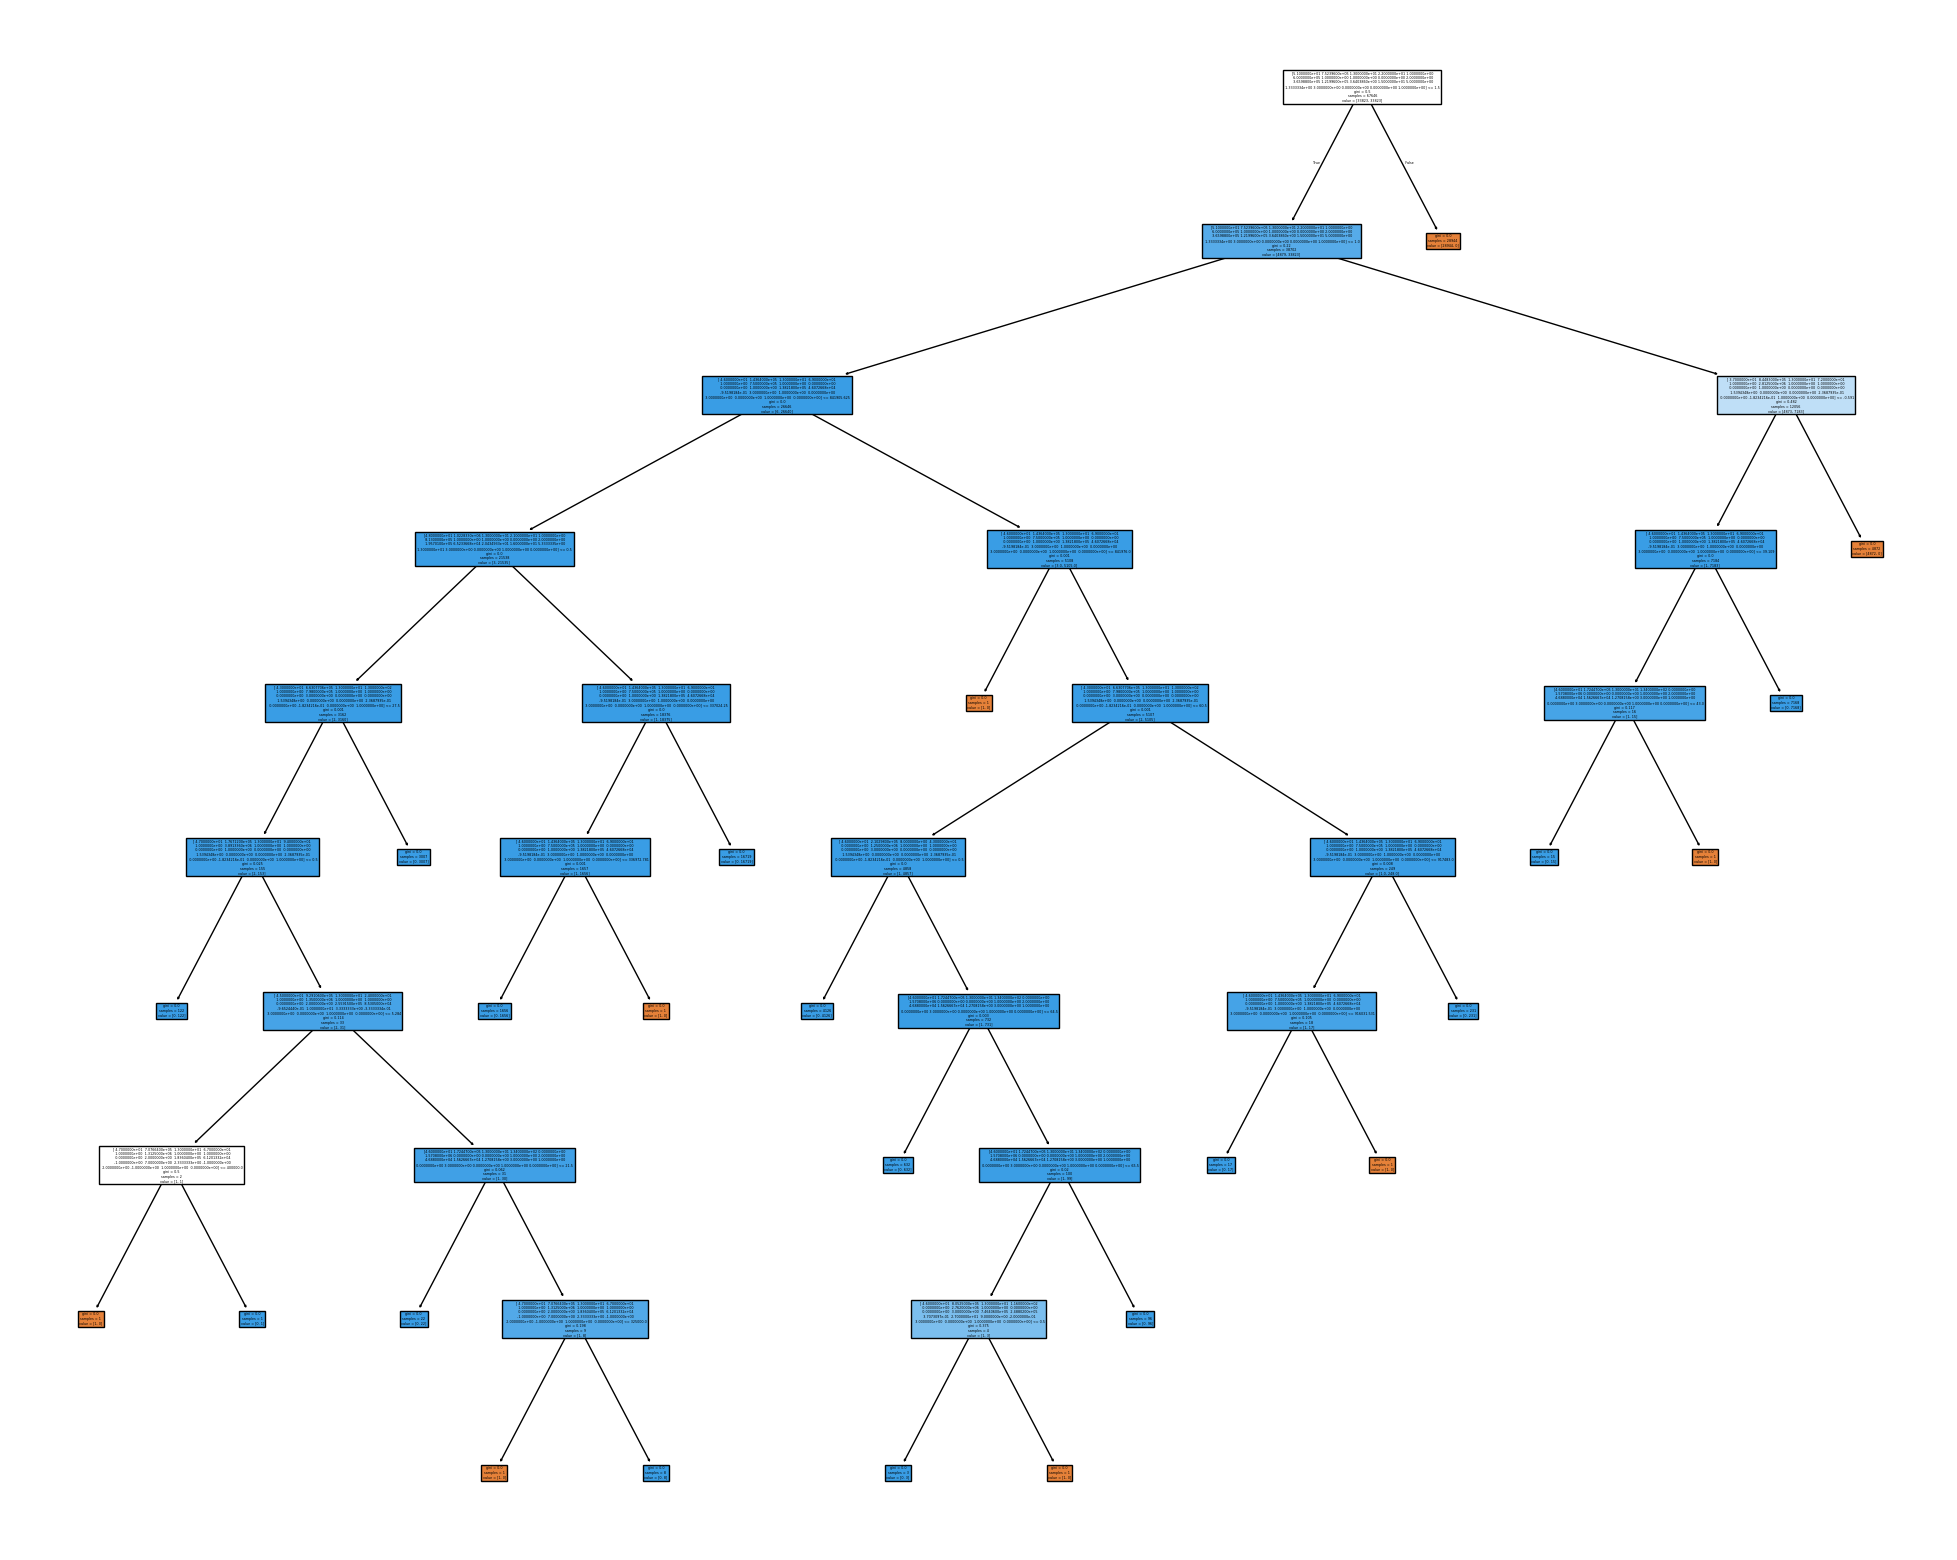

In [193]:
plot_decision_tree(dt_model, feature_names.values)

## Arbol de decision customizado

In [157]:
dt_custom_model = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=3, random_state=42)

In [195]:
dt_custom_model.fit(X_smo, y_smo.values.ravel())

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=3,
                       random_state=42)

In [197]:
y_pred_custom = dt_custom_model.predict(X_test)
evaluate_metrics(y_test, y_pred_custom)

{'accuracy': 0.9998044009779951,
 'recall': 1.0,
 'precision': 0.9988706945228685,
 'f1score': 0.9994350282485875}

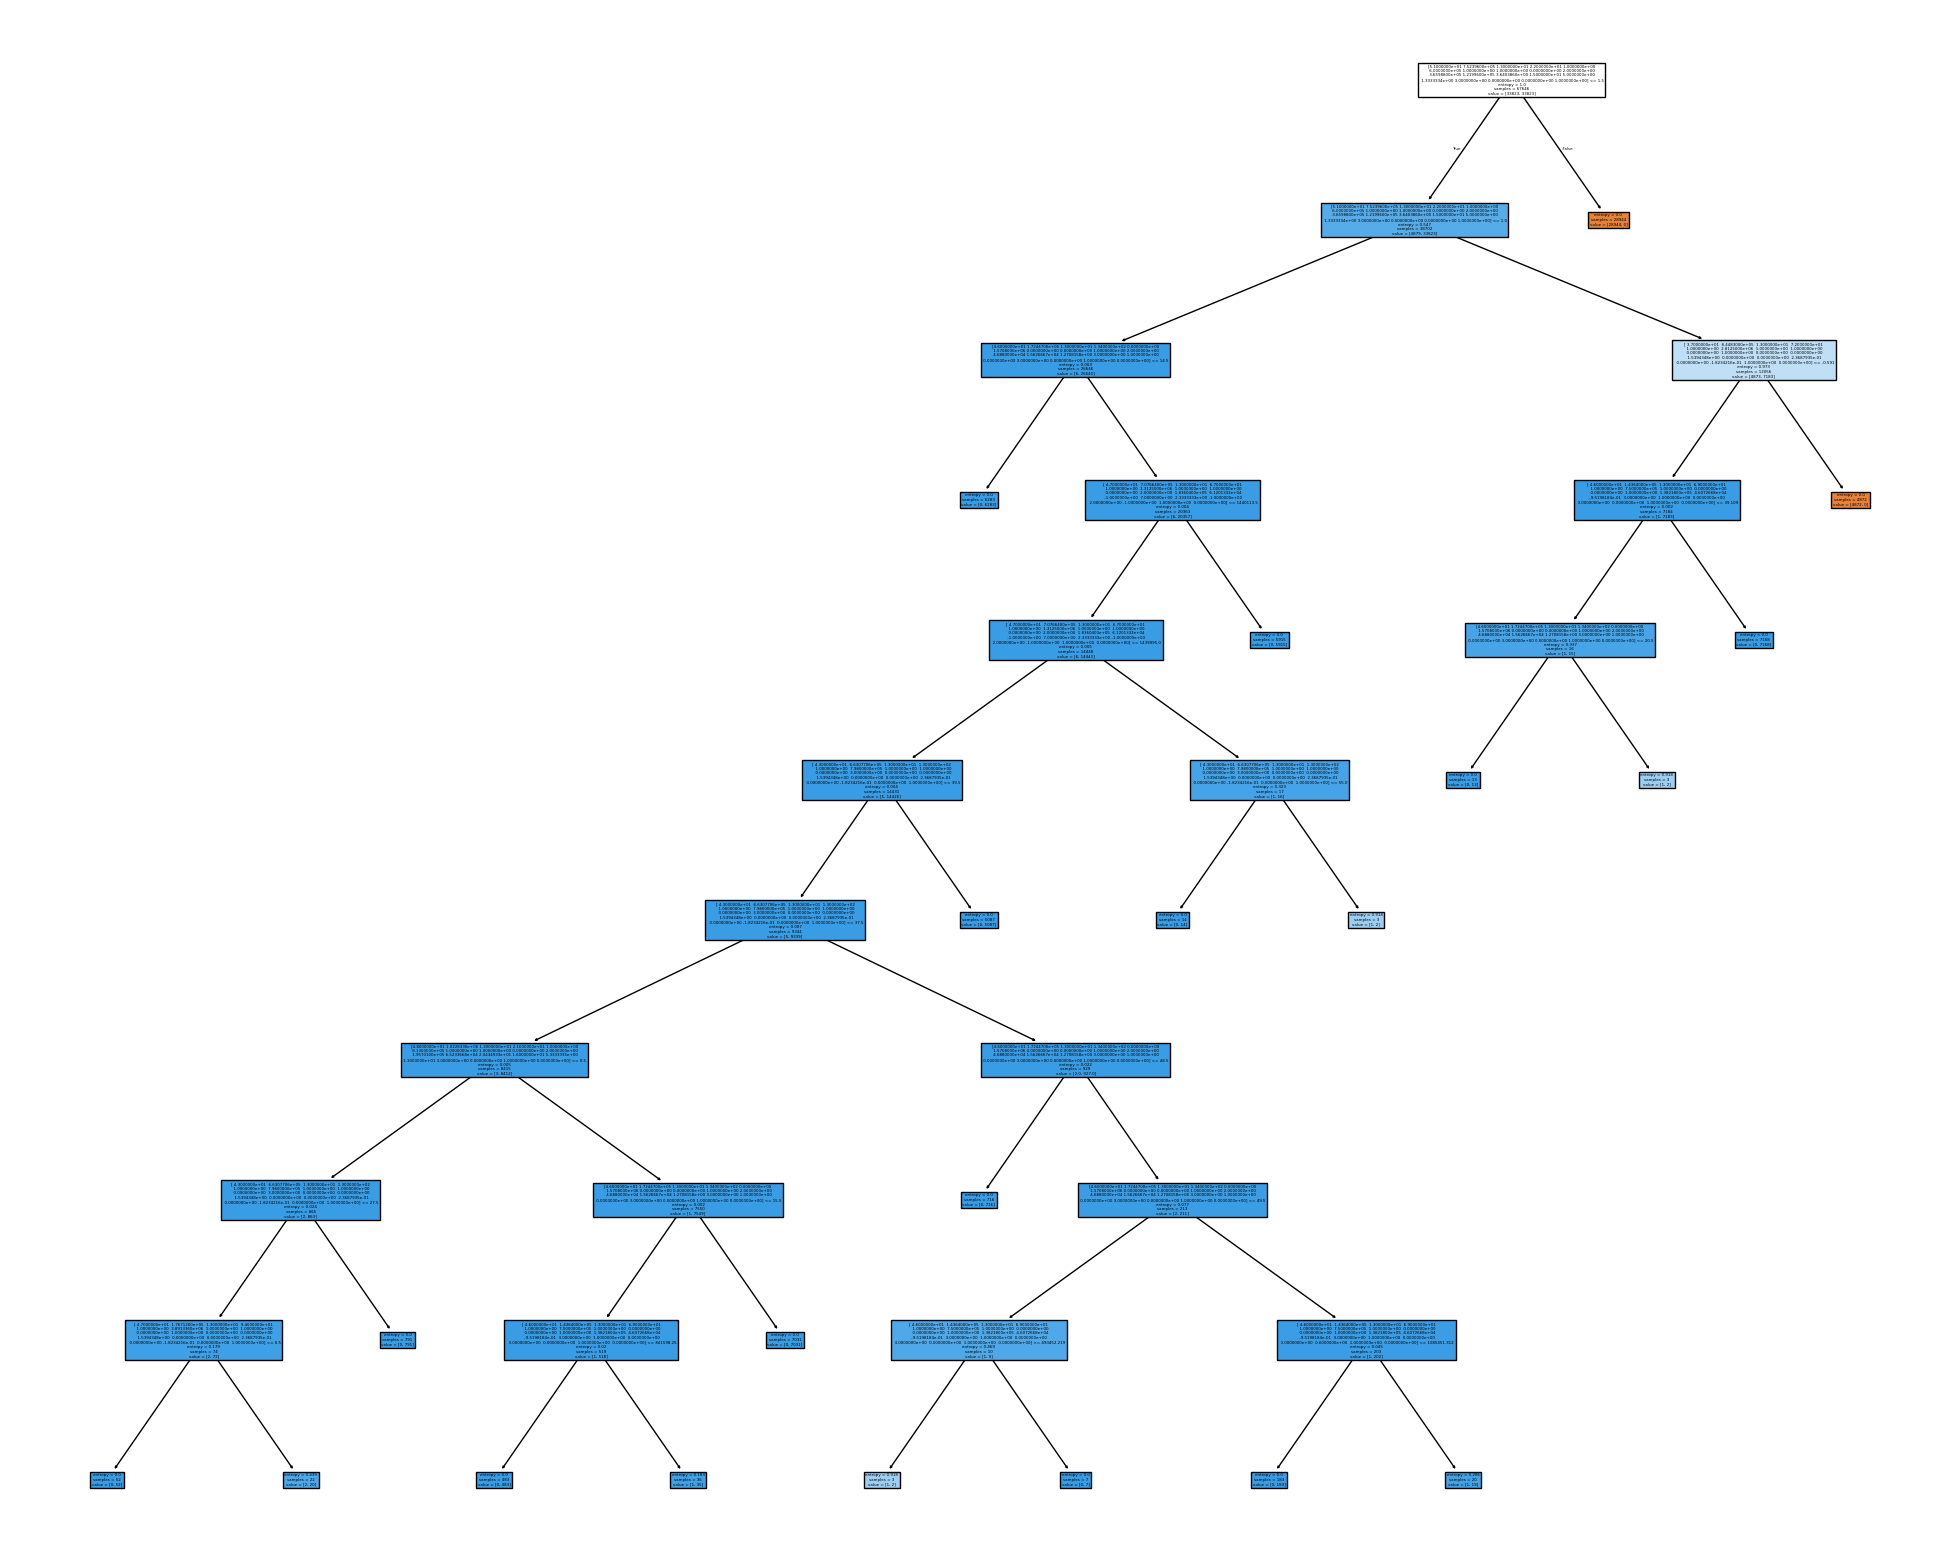

In [199]:
plot_decision_tree(dt_custom_model, feature_names.values)

In [201]:
params_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}

In [203]:
model = DecisionTreeClassifier(random_state=42)

In [205]:
grid_search = GridSearchCV(estimator = model, 
                        param_grid = params_grid, 
                        scoring='f1',
                        cv = 5, verbose = 1)
grid_search.fit(X_smo, y_smo.values.ravel())
best_params = grid_search.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [207]:
best_params

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}

In [209]:
dt_best_model = DecisionTreeClassifier(criterion='gini', max_depth= 5, min_samples_leaf= 5, random_state=42)

In [211]:
dt_best_model.fit(X_smo, y_smo.values.ravel())

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

In [213]:
y_best_model_pred = dt_best_model.predict(X_test)

In [215]:
evaluate_metrics(y_test, y_best_model_pred)

{'accuracy': 0.9998044009779951,
 'recall': 1.0,
 'precision': 0.9988706945228685,
 'f1score': 0.9994350282485875}

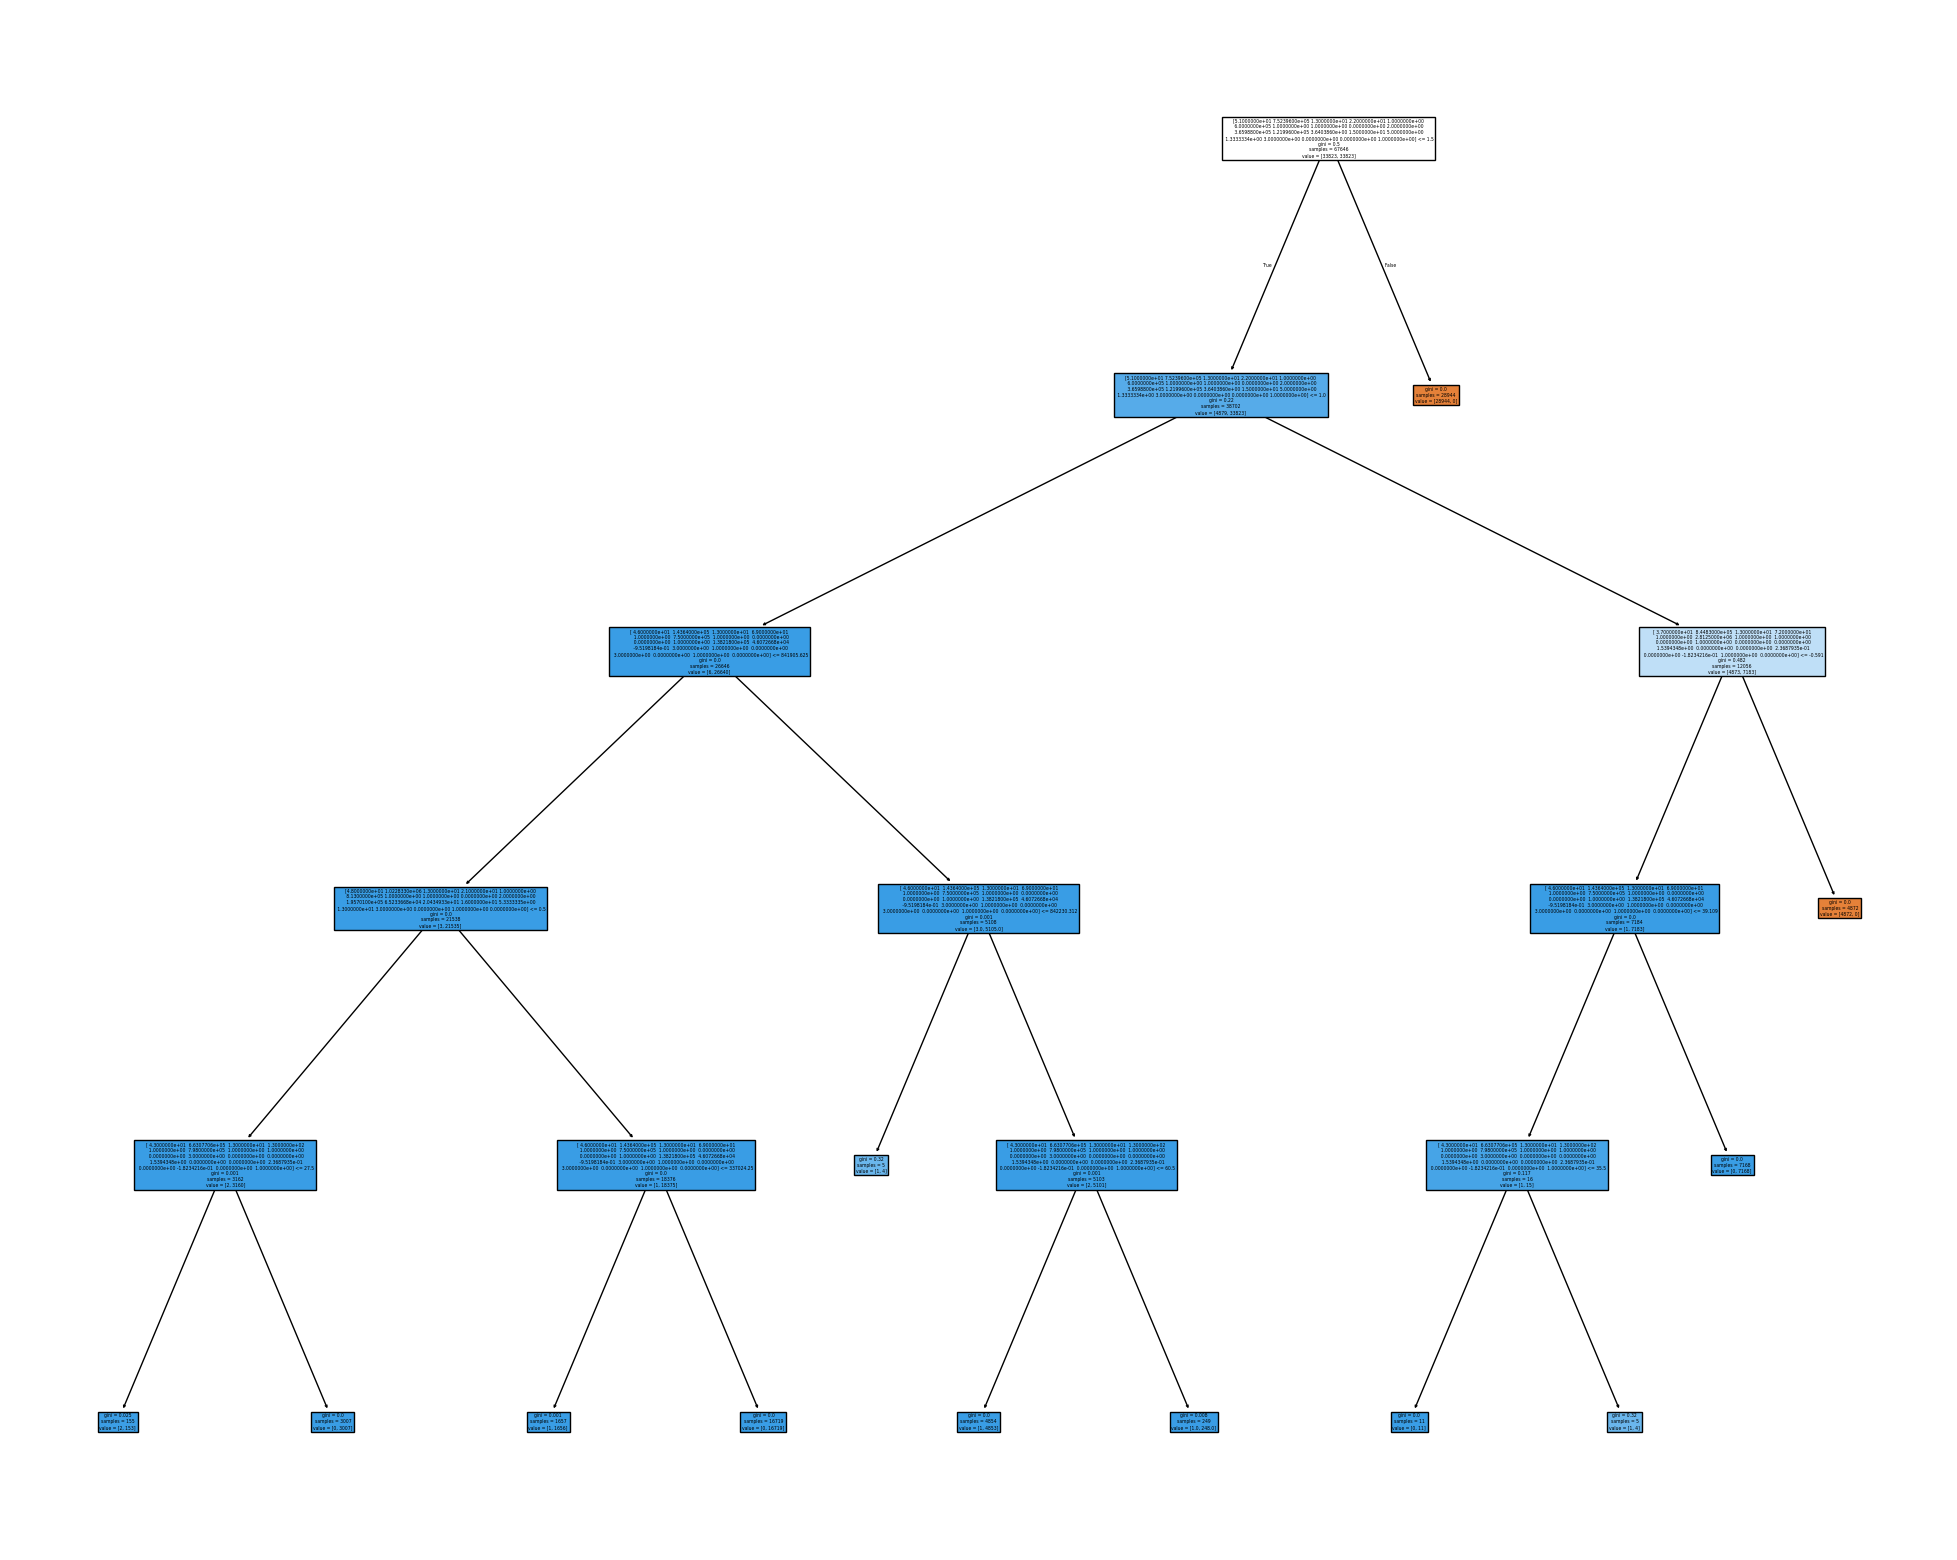

In [217]:
plot_decision_tree(dt_best_model, feature_names.values)

# Bagging

In [234]:
target = 'Churn'
ds[target].value_counts()

Churn
0    42279
1     8845
Name: count, dtype: int64

In [236]:
ds[target].value_counts(normalize=True)

Churn
0    0.826989
1    0.173011
Name: proportion, dtype: float64

In [246]:
from sklearn.model_selection import StratifiedShuffleSplit

feature_cols = [x for x in ds.columns if x != target]


# Split the data into two parts with 1500 points in the test data
# This creates a generator
strat_shuff_split = StratifiedShuffleSplit(n_splits=1, test_size=1500, random_state=42)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(ds[feature_cols], ds[target]))

# Create the data sets
X_train = ds.loc[train_idx, feature_cols]
y_train = ds.loc[train_idx, target]

X_test = ds.loc[test_idx, feature_cols]
y_test = ds.loc[test_idx, target]

In [248]:
y_train.value_counts(normalize=True)

Churn
0    0.826999
1    0.173001
Name: proportion, dtype: float64

In [250]:
y_test.value_counts(normalize=True)

Churn
0    0.826667
1    0.173333
Name: proportion, dtype: float64

In [254]:
param_grid = {
    'n_estimators': [2*n+1 for n in range(20)],
    'estimator__max_depth' : [2*n+1 for n in range(10) ]
    }

In [256]:
Bag = BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,bootstrap=True)

In [258]:
search = GridSearchCV(estimator=Bag, param_grid=param_grid,scoring='accuracy', cv=3)

In [260]:
search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(),
                                         random_state=0),
             param_grid={'estimator__max_depth': [1, 3, 5, 7, 9, 11, 13, 15, 17,
                                                  19],
                         'n_estimators': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
                                          23, 25, 27, 29, 31, 33, 35, 37, 39]},
             scoring='accuracy')

In [268]:
import joblib
joblib.dump(search, "modelo_bag.pkl")

['modelo_bag.pkl']

In [266]:
y_bag_pred = search.predict(X_test)

In [262]:
search.best_score_

0.9998186385801122

In [264]:
search.best_params_

{'estimator__max_depth': 3, 'n_estimators': 1}

In [270]:
evaluate_metrics(y_test, y_bag_pred)

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0, 'f1score': 1.0}